# Big Mart Sales Prediction using Linear Regression

## Objective: Predict Item_Outlet_Sales to help understand which product/outlet attributes drive revenue.

## Importing necessary libraries

In [9]:
#importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

In [12]:
# Read the dataset
# Note: Skipping first 5 rows as the CSV file has notes/description at the top
df = pd.read_csv(r"C:\Users\DELL\Downloads\big_mart_sales (1).csv")

## Data Overview

In [13]:
#Display first few records
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [14]:
#Display all information about columns, dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [15]:
#Display total number of rows & columns
df.shape

(8523, 12)

In [16]:
#Display all column names
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [17]:
#Display all statistical information for numerical columns
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [18]:
#Check Null values in each column
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

## Univariate Analysis

Descriptive statistics for Item_Outlet_Sales:
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


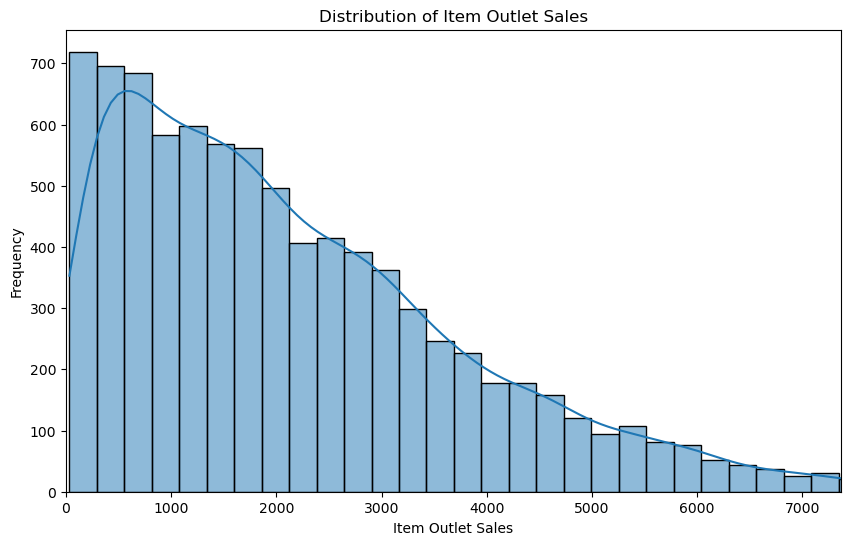

In [19]:
#Univariate analysis on the target column: Item_Outlet_Sales
# Descriptive statistics for Item_Outlet_Sales
print('Descriptive statistics for Item_Outlet_Sales:')
print(df['Item_Outlet_Sales'].describe())

# Histogram for Item_Outlet_Sales
plt.figure(figsize=(10, 6))
sns.histplot(df['Item_Outlet_Sales'], bins=50, kde=True)
plt.title('Distribution of Item Outlet Sales')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.xlim(0, df['Item_Outlet_Sales'].quantile(0.99)) 
plt.show()

Value counts for Item_Fat_Content:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


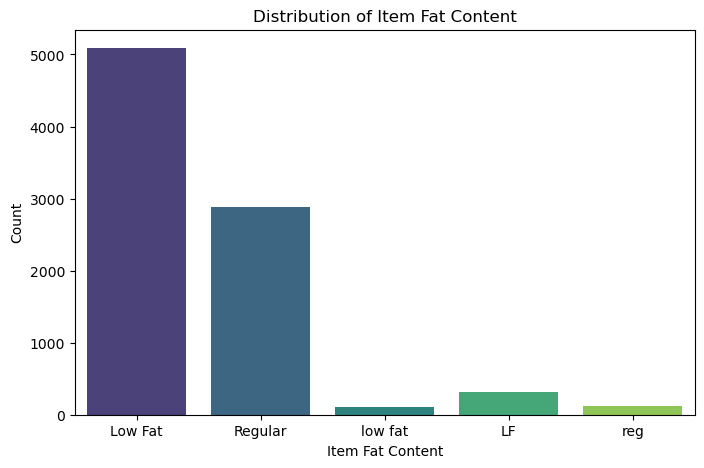

In [20]:
#Univariate Analysis for Item_Fat_Content
# Value counts for Item_Fat_Content
print('Value counts for Item_Fat_Content:')
print(df['Item_Fat_Content'].value_counts())

# Count plot for Item_Fat_Content
plt.figure(figsize=(8, 5))
sns.countplot(x='Item_Fat_Content', data=df, palette='viridis', hue='Item_Fat_Content', legend=False)
plt.title('Distribution of Item Fat Content')
plt.xlabel('Item Fat Content')
plt.ylabel('Count')
plt.show()

Value counts for Item_Type:
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


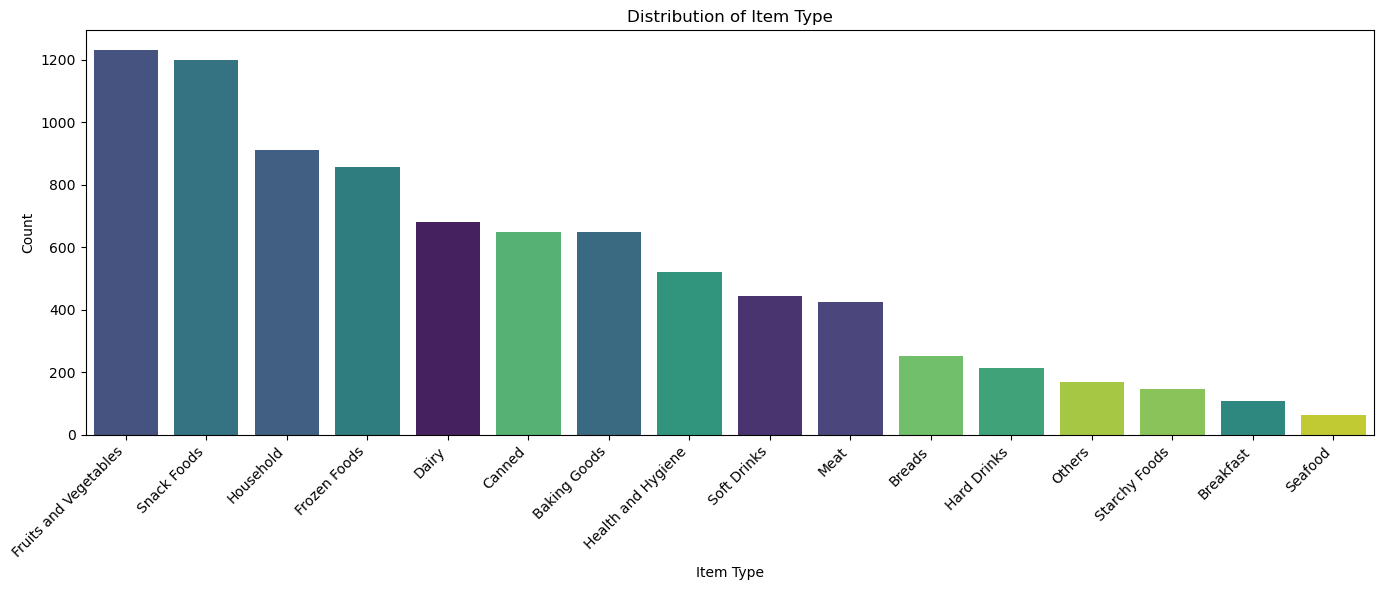

In [21]:
#Univariate Analysis for Item_Type
# Value counts for Item_Type
print('Value counts for Item_Type:')
print(df['Item_Type'].value_counts())

# Count plot for Item_Type
plt.figure(figsize=(14, 6))
sns.countplot(x='Item_Type', data=df, palette='viridis', hue='Item_Type', legend=False,
              order=df['Item_Type'].value_counts().index)
plt.title('Distribution of Item Type')
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Descriptive statistics for Outlet_Establishment_Year:
count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64


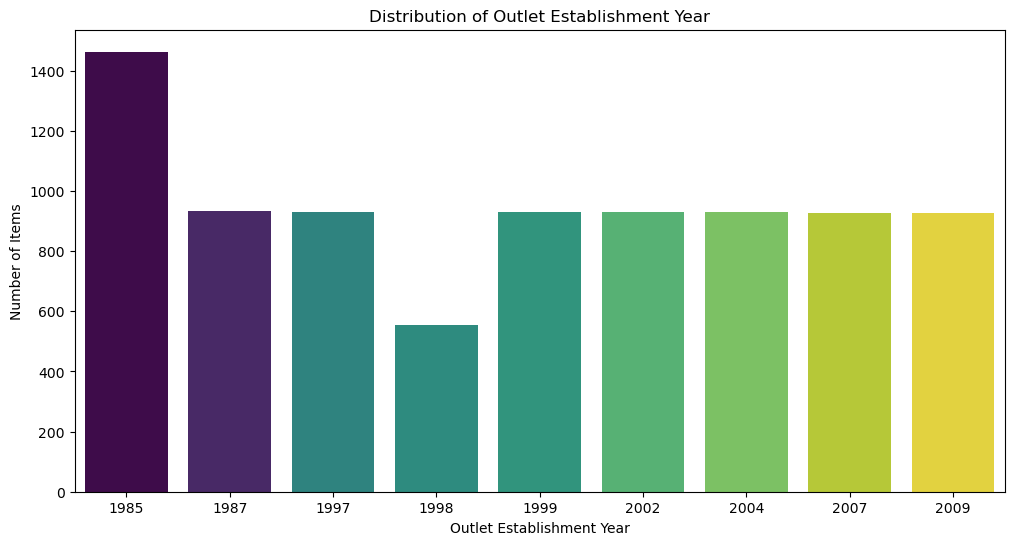

In [22]:
#Univariate Analysis for Outlet_Establishment_Year
# Descriptive statistics for Outlet_Establishment_Year
print('Descriptive statistics for Outlet_Establishment_Year:')
print(df['Outlet_Establishment_Year'].describe())

# Count plot for Outlet_Establishment_Year
plt.figure(figsize=(12, 6))
sns.countplot(x='Outlet_Establishment_Year', data=df, palette='viridis',
              hue='Outlet_Establishment_Year', legend=False)
plt.title('Distribution of Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Number of Items')
plt.show()

Value counts for Outlet_Size:
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

Value counts for Outlet_Location_Type:
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


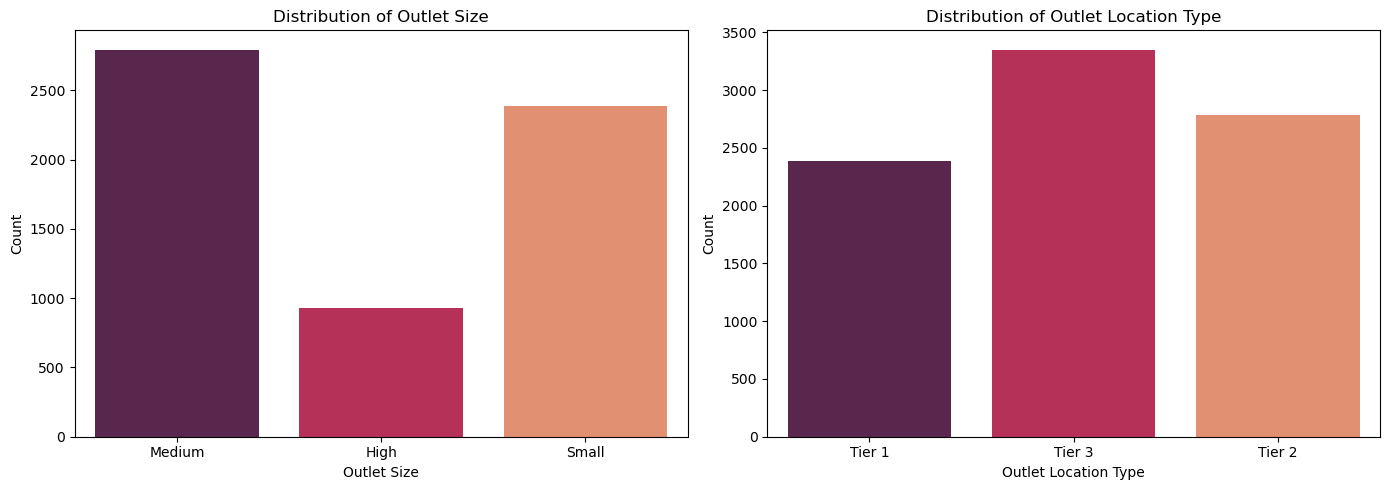

In [23]:
#Univariate Analysis for Outlet_Size and Outlet_Location_Type
# Value counts
print('Value counts for Outlet_Size:')
print(df['Outlet_Size'].value_counts())
print('\nValue counts for Outlet_Location_Type:')
print(df['Outlet_Location_Type'].value_counts())

# Count plots side by side
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Outlet_Size', data=df, palette='rocket', hue='Outlet_Size', legend=False)
plt.title('Distribution of Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Outlet_Location_Type', data=df, palette='rocket', hue='Outlet_Location_Type', legend=False)
plt.title('Distribution of Outlet Location Type')
plt.xlabel('Outlet Location Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Descriptive statistics for Item_Weight:
count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64

Descriptive statistics for Item_Visibility:
count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64

Descriptive statistics for Item_MRP:
count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64


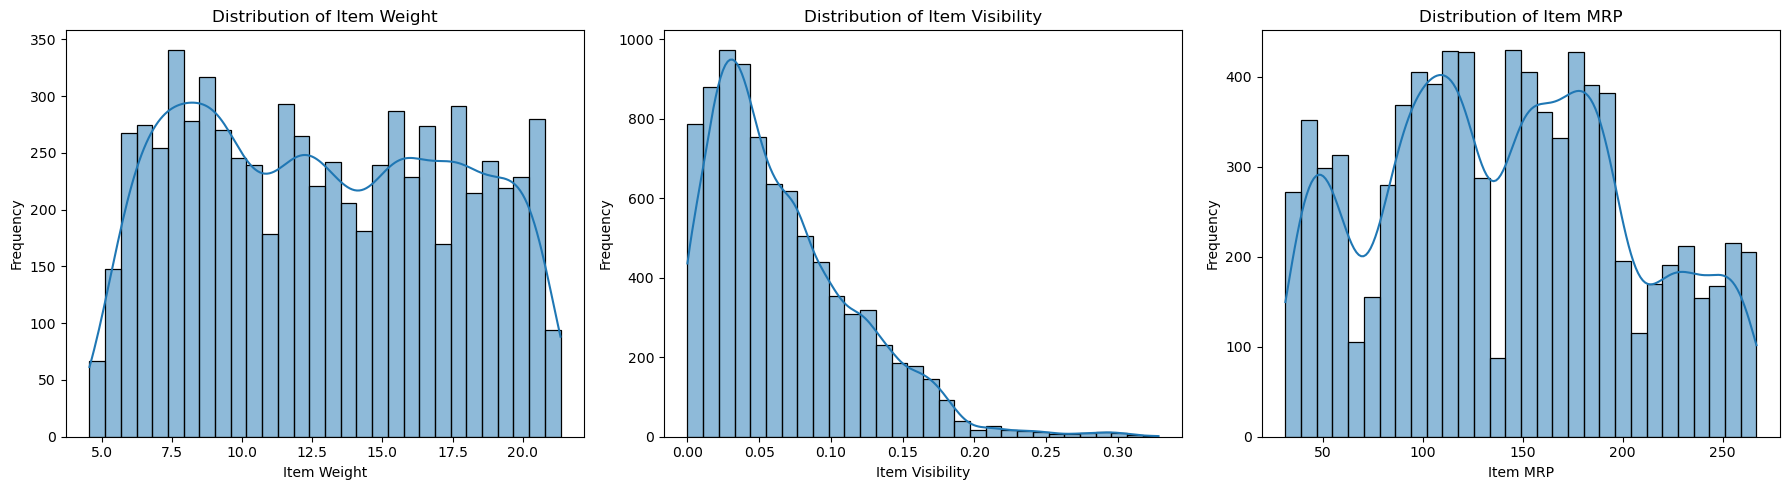

In [24]:
#Univariate Analysis for numerical features: Item_Weight, Item_Visibility, Item_MRP
# Descriptive statistics
print('Descriptive statistics for Item_Weight:')
print(df['Item_Weight'].describe())
print('\nDescriptive statistics for Item_Visibility:')
print(df['Item_Visibility'].describe())
print('\nDescriptive statistics for Item_MRP:')
print(df['Item_MRP'].describe())

# Histograms for numerical features
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Item_Weight'].dropna(), bins=30, kde=True)
plt.title('Distribution of Item Weight')
plt.xlabel('Item Weight')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['Item_Visibility'], bins=30, kde=True)
plt.title('Distribution of Item Visibility')
plt.xlabel('Item Visibility')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['Item_MRP'], bins=30, kde=True)
plt.title('Distribution of Item MRP')
plt.xlabel('Item MRP')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Bivariate Analysis

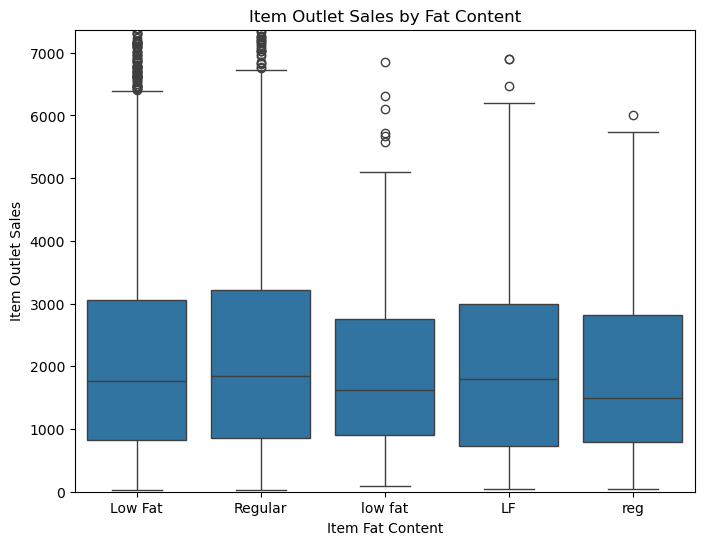

In [25]:
#Item_Outlet_Sales vs Item_Fat_Content
plt.figure(figsize=(8, 6))
sns.boxplot(x='Item_Fat_Content', y='Item_Outlet_Sales', data=df)
plt.title('Item Outlet Sales by Fat Content')
plt.xlabel('Item Fat Content')
plt.ylabel('Item Outlet Sales')
plt.ylim(0, df['Item_Outlet_Sales'].quantile(0.99))
plt.show()

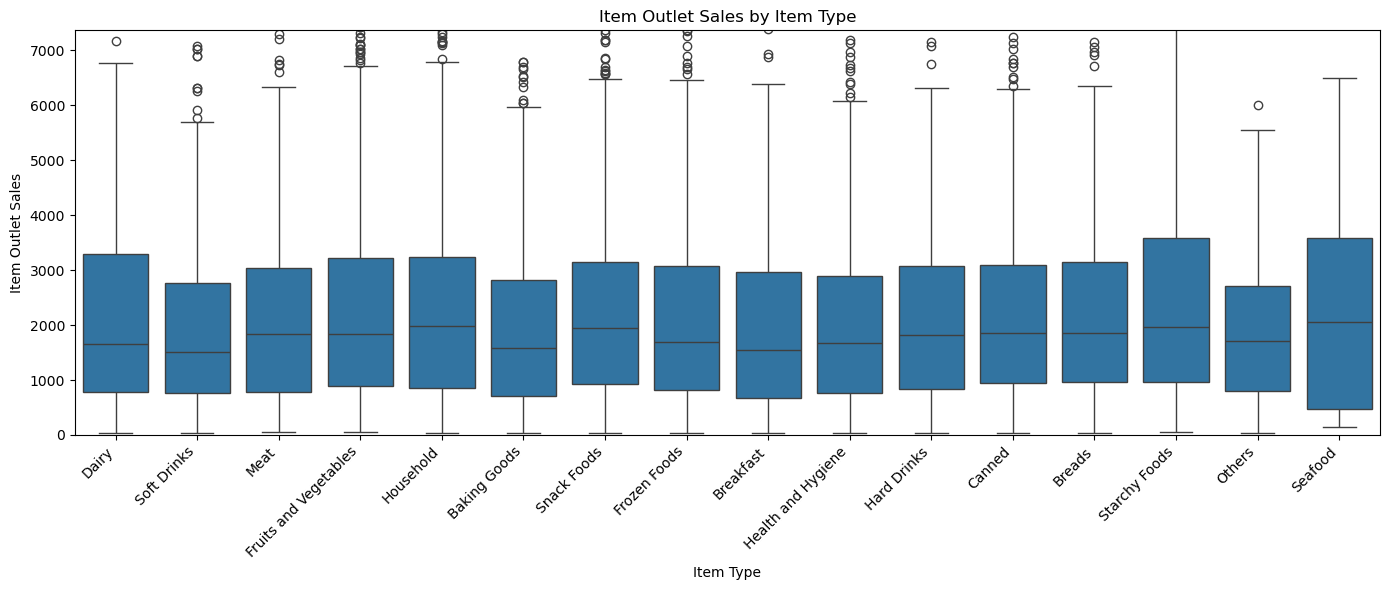

In [26]:
#Item_Outlet_Sales vs Item_Type
plt.figure(figsize=(14, 6))
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df)
plt.title('Item Outlet Sales by Item Type')
plt.xlabel('Item Type')
plt.ylabel('Item Outlet Sales')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df['Item_Outlet_Sales'].quantile(0.99))
plt.tight_layout()
plt.show()

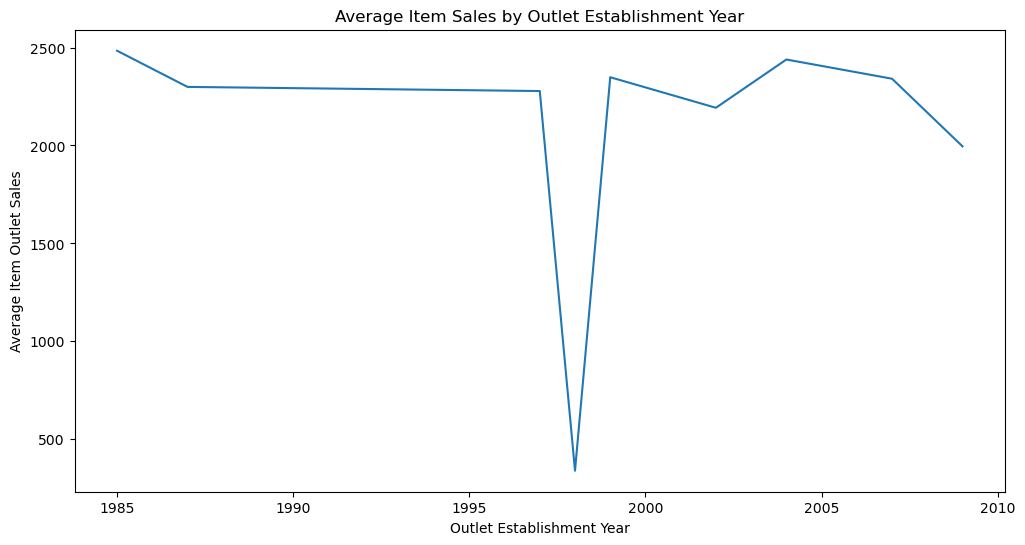

In [27]:
#Item_Outlet_Sales vs Outlet_Establishment_Year
# Average sales per establishment year
avg_sales_year = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data=avg_sales_year)
plt.title('Average Item Sales by Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Average Item Outlet Sales')
plt.show()

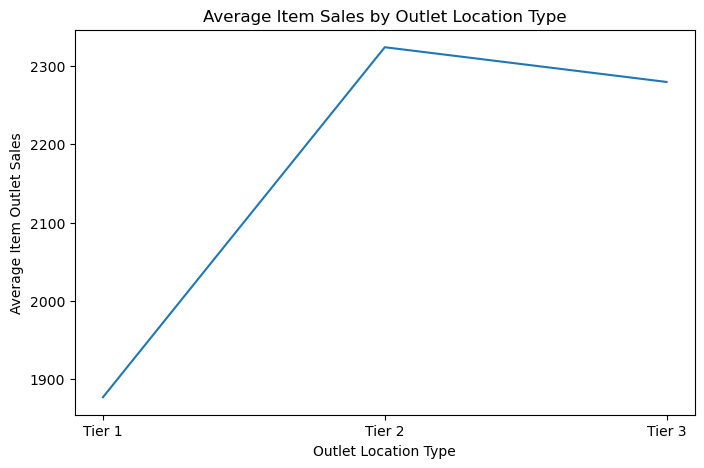

In [28]:
#Item_Outlet_Sales vs Outlet_Location_Type
# Average sales per outlet location type
avg_sales_loc = df.groupby('Outlet_Location_Type')['Item_Outlet_Sales'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=avg_sales_loc)
plt.title('Average Item Sales by Outlet Location Type')
plt.xlabel('Outlet Location Type')
plt.ylabel('Average Item Outlet Sales')
plt.show()

## Pair Plot

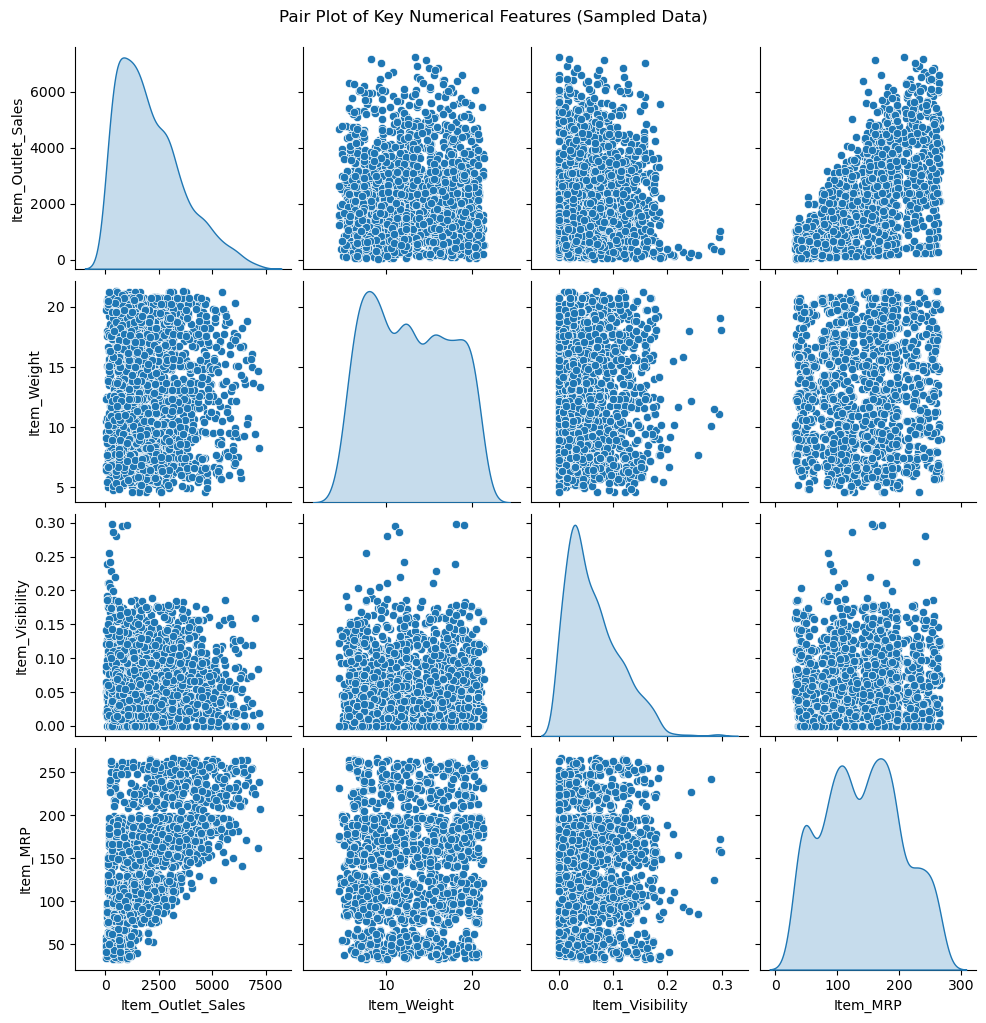

In [29]:
# Select a subset of numerical features for the pair plot
features_for_pairplot = ['Item_Outlet_Sales', 'Item_Weight', 'Item_Visibility', 'Item_MRP']
df_pairplot = df[features_for_pairplot].dropna().copy()

# Sample the data for the pair plot to improve performance and readability
df_pairplot_sample = df_pairplot.sample(n=min(2000, len(df_pairplot)), random_state=42)

# Limit Item_Outlet_Sales for better visualization
df_pairplot_sample = df_pairplot_sample[
    df_pairplot_sample['Item_Outlet_Sales'] < df['Item_Outlet_Sales'].quantile(0.99)
]

# Create the pair plot
sns.pairplot(df_pairplot_sample, diag_kind='kde')
plt.suptitle('Pair Plot of Key Numerical Features (Sampled Data)', y=1.02)
plt.show()

## Correlation Heatmap

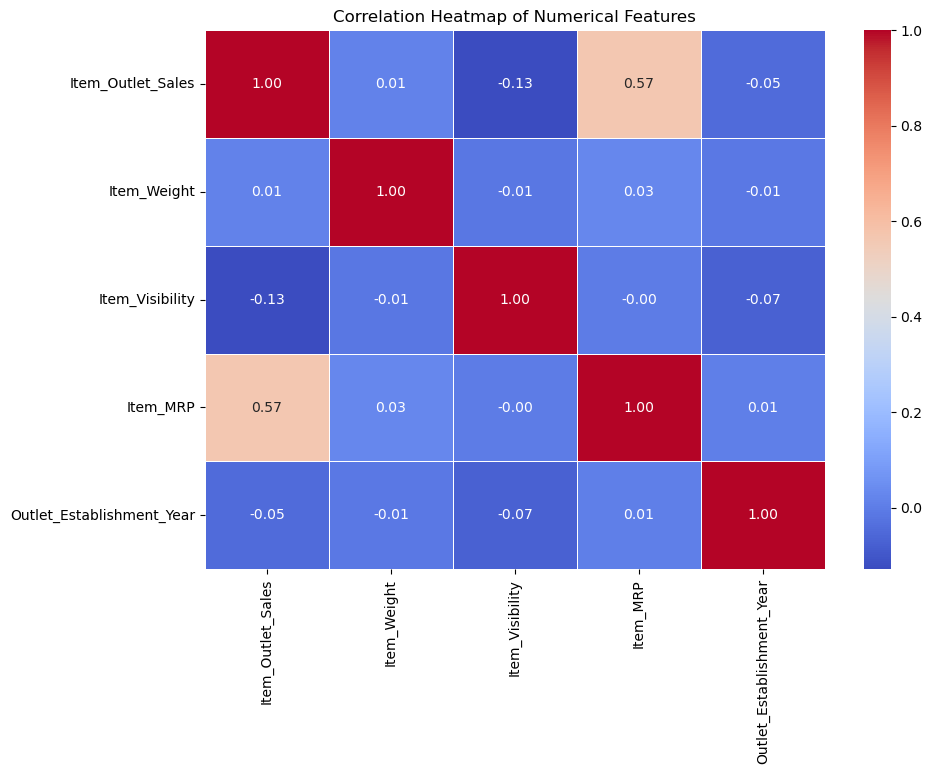

In [30]:
# Select numerical features for heatmap
features_for_heatmap = ['Item_Outlet_Sales', 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
df_heatmap = df[features_for_heatmap]

# Calculate the correlation matrix
correlation_matrix = df_heatmap.corr()

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Outlier Analysis

Original Item_Outlet_Sales min: 33.29
Original Item_Outlet_Sales max: 13086.9648
Lower bound (0.01 percentile): 33.29
Upper bound (99.99 percentile): 12260.838029438859

Shape before filtering outliers: (8523, 12)
Shape after filtering outliers: (8522, 12)

Descriptive statistics for filtered Item_Outlet_Sales:
count     8522.000000
mean      2180.009205
std       1702.505018
min         33.290000
25%        833.914500
50%       1794.331000
75%       3100.963500
max      12117.560000
Name: Item_Outlet_Sales, dtype: float64


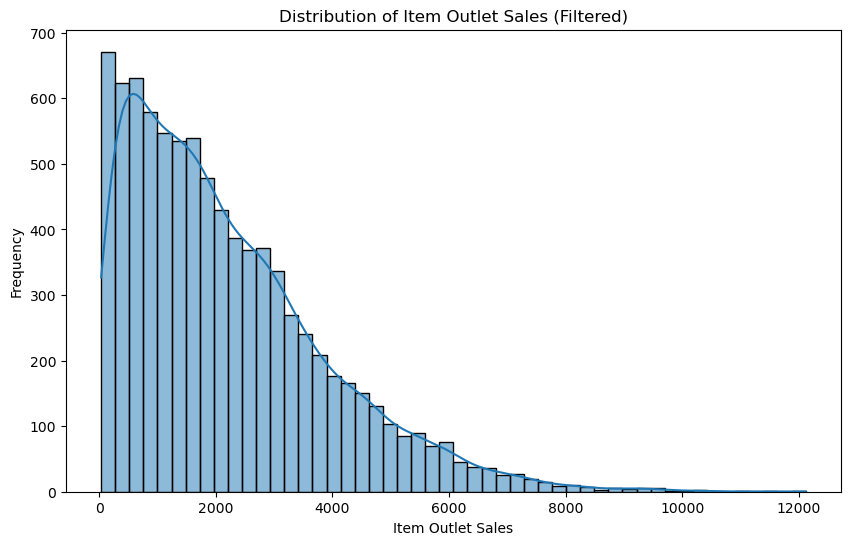

In [31]:
#Outliers in Item_Outlet_Sales

# Calculate the 0.01 and 99.99 percentiles for Item_Outlet_Sales
lower_bound = df['Item_Outlet_Sales'].quantile(0.0001)
upper_bound = df['Item_Outlet_Sales'].quantile(0.9999)

print(f"Original Item_Outlet_Sales min: {df['Item_Outlet_Sales'].min()}")
print(f"Original Item_Outlet_Sales max: {df['Item_Outlet_Sales'].max()}")
print(f"Lower bound (0.01 percentile): {lower_bound}")
print(f"Upper bound (99.99 percentile): {upper_bound}")

# Filter out outliers
df_filtered = df[
    (df['Item_Outlet_Sales'] >= lower_bound) & (df['Item_Outlet_Sales'] <= upper_bound)
].copy()

print(f"\nShape before filtering outliers: {df.shape}")
print(f"Shape after filtering outliers: {df_filtered.shape}")

# Re-check descriptive statistics after filtering
print('\nDescriptive statistics for filtered Item_Outlet_Sales:')
print(df_filtered['Item_Outlet_Sales'].describe())

# Visualize the distribution after filtering
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['Item_Outlet_Sales'], bins=50, kde=True)
plt.title('Distribution of Item Outlet Sales (Filtered)')
plt.xlabel('Item Outlet Sales')
plt.ylabel('Frequency')
plt.show()

Number of items with 0 visibility: 526
After replacing 0 visibility:
count    8522.000000
mean        0.070216
std         0.048753
min         0.003575
25%         0.033092
50%         0.061378
75%         0.094594
max         0.328391
Name: Item_Visibility, dtype: float64


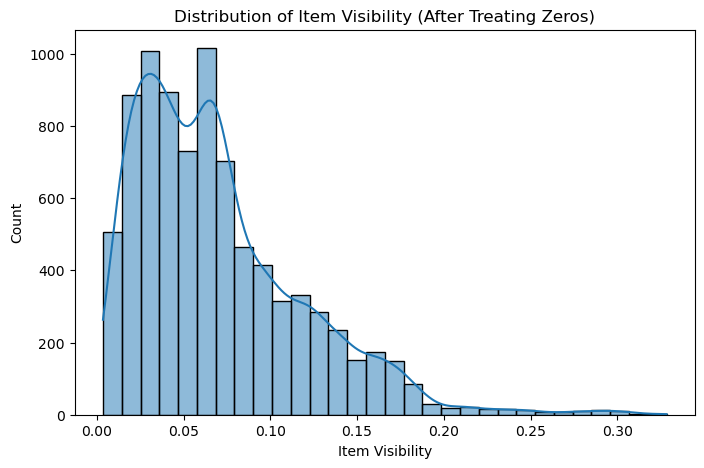

In [32]:
#Outliers in Item_Visibility
# Item_Visibility = 0 is suspicious — item exists in store but has 0 visibility
# Replace 0 visibility with the mean visibility of that Item_Type
print(f"Number of items with 0 visibility: {(df_filtered['Item_Visibility'] == 0).sum()}")

# Replace 0 visibility with mean visibility per Item_Type
df_filtered['Item_Visibility'] = df_filtered.groupby('Item_Type')['Item_Visibility'].transform(
    lambda x: x.replace(0, x.mean())
)

print(f"After replacing 0 visibility:")
print(df_filtered['Item_Visibility'].describe())

# Visualize after treatment
plt.figure(figsize=(8, 5))
sns.histplot(df_filtered['Item_Visibility'], bins=30, kde=True)
plt.title('Distribution of Item Visibility (After Treating Zeros)')
plt.xlabel('Item Visibility')
plt.ylabel('Count')
plt.show()

In [33]:
#Outliers in Item_Fat_Content
# Fix inconsistent labels: 'LF', 'low fat' -> 'Low Fat'; 'reg' -> 'Regular'
print("Before fixing Fat Content labels:")
print(df_filtered['Item_Fat_Content'].value_counts())

df_filtered['Item_Fat_Content'] = df_filtered['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

print("\nAfter fixing Fat Content labels:")
print(df_filtered['Item_Fat_Content'].value_counts())

Before fixing Fat Content labels:
Item_Fat_Content
Low Fat    5088
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After fixing Fat Content labels:
Item_Fat_Content
Low Fat    5516
Regular    3006
Name: count, dtype: int64


In [34]:
#Handle Missing Values
# Fill missing Item_Weight with mean weight per Item_Type
df_filtered['Item_Weight'] = df_filtered.groupby('Item_Type')['Item_Weight'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing Outlet_Size with mode per Outlet_Type
outlet_size_mode = df_filtered.groupby('Outlet_Type')['Outlet_Size'].apply(
    lambda x: x.mode()[0] if not x.mode().empty else 'Medium'
)
df_filtered['Outlet_Size'] = df_filtered.apply(
    lambda row: outlet_size_mode[row['Outlet_Type']] if pd.isnull(row['Outlet_Size']) else row['Outlet_Size'],
    axis=1
)

print("Missing values after treatment:")
print(df_filtered.isnull().sum())

Missing values after treatment:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


## Model Building

In [35]:
#Define Features and Target
from sklearn.model_selection import train_test_split

# Drop columns not useful for model: identifiers
drop_cols = ['Item_Identifier', 'Outlet_Identifier']

df_model = df_filtered.drop(columns=drop_cols).copy()

# One-hot encode all categorical columns
df_model = pd.get_dummies(df_model, drop_first=True)

# Define features (X) and target (y)
X = df_model.drop('Item_Outlet_Sales', axis=1)
y = df_model['Item_Outlet_Sales']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("Selected Features:")
print(X.columns.tolist())

Features (X) shape: (8522, 27)
Target (y) shape: (8522,)
Selected Features:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Fat_Content_Regular', 'Item_Type_Breads', 'Item_Type_Breakfast', 'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods', 'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks', 'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat', 'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods', 'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods', 'Outlet_Size_Medium', 'Outlet_Size_Small', 'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3', 'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3']


In [36]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6817, 27)
X_test shape: (1705, 27)
y_train shape: (6817,)
y_test shape: (1705,)


In [37]:
#Linear Regression Model
#Choose a Model & Train the Model

from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_model = LinearRegression()

print("Training Linear Regression model...")
# Train the model on training data
linear_model.fit(X_train, y_train)

print("Linear Regression model training complete.")

Training Linear Regression model...
Linear Regression model training complete.


Linear Regression Model Evaluation on Test Set:
RMSE: 1063.7708
MAE: 766.2042
R-squared: 0.5879


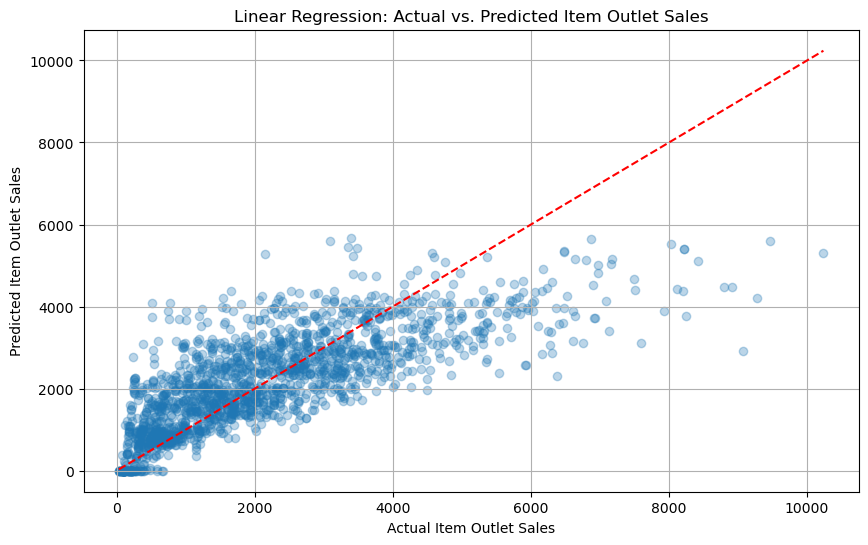

In [38]:
#Evaluate the Model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Ensure predictions are non-negative (sales cannot be negative)
y_pred_linear[y_pred_linear < 0] = 0

# Evaluate the model
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression Model Evaluation on Test Set:")
print(f"RMSE: {rmse_linear:.4f}")
print(f"MAE: {mae_linear:.4f}")
print(f"R-squared: {r2_linear:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Item Outlet Sales')
plt.ylabel('Predicted Item Outlet Sales')
plt.title('Linear Regression: Actual vs. Predicted Item Outlet Sales')
plt.grid(True)
plt.show()

## Conclusion: Linear Regression gives a solid baseline; Item_MRP is the strongest predictor. Non-linear models like Random Forest could further improve accuracy.